<a href="https://colab.research.google.com/github/antonellagambarte/proyecto-final-CEIA/blob/main/PRUEBA_ETAPA_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

In [73]:
ruta_archivo_train = '/content/drive/My Drive/NHANES/dataset_train_imputado.csv'
ruta_archivo_test = '/content/drive/My Drive/NHANES/dataset_test_imputado.csv'


df_train = pd.read_csv(ruta_archivo_train)
df_test = pd.read_csv(ruta_archivo_test)

In [74]:
df_train.head()

,edad,genero,colesterol_total,hdl,ldl,trigliceridos,proteina_c,bmi,fumo_100_cigarrillos,fumador_actual,...,consumo_excesivo_alcohol_ultimo_año_8.0,consumo_excesivo_alcohol_ultimo_año_9.0,consumo_excesivo_alcohol_ultimo_año_10.0,consumo_excesivo_alcohol_ultimo_año_22.0,consumo_excesivo_alcohol_ultimo_año_23.0,consumo_excesivo_alcohol_ultimo_año_99.0,anhedonia_1.0,anhedonia_2.0,anhedonia_3.0,anhedonia_9.0
0,0.027815,1,0.635525,-0.409169,110.804858,1.430187,-0.633385,-0.926269,1,-0.450093,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.598832,1,-0.236009,0.044620,100.609504,-0.035063,-0.681892,-1.527568,0,-0.450093,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.869431,1,-0.154793,-0.056492,105.080360,-0.040414,-0.646549,-0.547527,1,2.387436,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,-0.084401,1,0.421306,0.838667,118.001130,-0.366252,-0.041933,-0.024172,0,-0.450093,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.589371,0,0.226934,-0.409169,112.161330,0.702848,0.117120,0.260671,0,-0.450093,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [75]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4454 entries, 0 to 4453
Data columns (total 83 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   edad                                      4454 non-null   float64
 1   genero                                    4454 non-null   int64  
 2   colesterol_total                          4454 non-null   float64
 3   hdl                                       4454 non-null   float64
 4   ldl                                       4454 non-null   float64
 5   trigliceridos                             4454 non-null   float64
 6   proteina_c                                4454 non-null   float64
 7   bmi                                       4454 non-null   float64
 8   fumo_100_cigarrillos                      4454 non-null   int64  
 9   fumador_actual                            4454 non-null   float64
 10  act_vigorosa                        

In [76]:
nivel_1_basico = [
    'edad', 'genero', 'fumo_100_cigarrillos', 'actividad_deportiva_moderada_x_semana', 'anhedonia_1.0', 'anhedonia_2.0', 'anhedonia_9.0',
    'anhedonia_3.0', 'consumo_alcohol_ultimo_año_1.0', 'consumo_alcohol_ultimo_año_2.0', 'consumo_alcohol_ultimo_año_3.0',
    'consumo_alcohol_ultimo_año_4.0', 'consumo_alcohol_ultimo_año_5.0', 'consumo_alcohol_ultimo_año_6.0', 'consumo_alcohol_ultimo_año_7.0',
    'consumo_alcohol_ultimo_año_8.0', 'consumo_alcohol_ultimo_año_9.0', 'consumo_alcohol_ultimo_año_10.0', 'consumo_alcohol_ultimo_año_20.0',
    'consumo_alcohol_ultimo_año_99.0',
]

# ETAPA 2
nivel_2_antecedentes = [
     'bmi', 'presion_sistolica_final', 'presion_diastolica_final', 'fam_cardio_2.0','fam_cardio_9.0', 'fam_diabetes_2.0','fam_diabetes_9.0',
     'fam_asma_2.0', 'fam_asma_9.0', 'hipertension_2','hipertension_9', 'diabetes_2.0', 'diabetes_3.0','diabetes_9.0',
     'riñones_debiles_fallando_2.0','riñones_debiles_fallando_9.0'
]



# # # ETAPA 3: Análisis de Laboratorio
nivel_3_laboratorio = [
   'colesterol_total', 'hdl', 'trigliceridos', 'proteina_c', 'hemoglobina', 'creatinina', 'acido_urico', 'potasio'
]

In [77]:
from sklearn.metrics import (
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluar_overfitting(
    modelo,
    X_train, y_train,
    X_test, y_test,
    threshold=0.25,
    nombre="Modelo"
):

    # Probabilidades
    prob_train = modelo.predict_proba(X_train)[:, 1]
    prob_test = modelo.predict_proba(X_test)[:, 1]

    # Predicciones binarias
    pred_train = (prob_train >= threshold).astype(int)
    pred_test = (prob_test >= threshold).astype(int)

    # Métricas train
    auc_train = roc_auc_score(y_train, prob_train)
    recall_train = recall_score(y_train, pred_train)
    precision_train = precision_score(y_train, pred_train)
    f1_train = f1_score(y_train, pred_train)

    # Métricas test
    auc_test = roc_auc_score(y_test, prob_test)
    recall_test = recall_score(y_test, pred_test)
    precision_test = precision_score(y_test, pred_test)
    f1_test = f1_score(y_test, pred_test)

    print(f"\n===== {nombre} ====")
    print("---- TRAIN ----")
    print(f"AUC: {auc_train:.4f}")
    print(f"Recall: {recall_train:.4f}")
    print(f"Precision: {precision_train:.4f}")
    print(f"F1: {f1_train:.4f}")

    print("\n---- TEST ----")
    print(f"AUC: {auc_test:.4f}")
    print(f"Recall: {recall_test:.4f}")
    print(f"Precision: {precision_test:.4f}")
    print(f"F1: {f1_test:.4f}")

    auc_gap = auc_train - auc_test
    recall_gap = recall_train - recall_test
    print(f"\n---- GAP (Train-Test) ----")
    print(f"AUC gap: {auc_gap:.4f}")
    print(f"Recall gap: {recall_gap:.4f}")

    # Matriz de confusión para el conjunto de prueba
    cm = confusion_matrix(y_test, pred_test)
    labels = ["Bajo riesgo", "Alto riesgo"]

    # Normalizar la matriz de confusión para mostrar porcentajes
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".2%", # Formato de porcentaje con 2 decimales
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.title(f"Matriz de Confusión Normalizada - {nombre} (TEST)")
    plt.show()

    return {
        "auc_train": auc_train,
        "recall_train": recall_train,
        "precision_train": precision_train,
        "f1_train": f1_train,
        "auc_test": auc_test,
        "recall_test": recall_test,
        "precision_test": precision_test,
        "f1_test": f1_test,
        "auc_gap": auc_gap,
        "recall_gap": recall_gap
    }

In [78]:
# Inicializamos la lista para almacenar los resultados de los modelos
results = []

In [79]:
df_results = pd.DataFrame(results)

In [80]:
df_train_temp = df_train.copy()
df_test_temp = df_test.copy()

In [81]:
TARGET = "alto_riesgo"

X_train = df_train_temp.drop(columns=[TARGET])
y_train = df_train_temp[TARGET]

X_test = df_test_temp.drop(columns=[TARGET])
y_test = df_test_temp[TARGET]

In [82]:
nivel_1_cols = [c for c in nivel_1_basico if c in X_train.columns]
nivel_2_cols = nivel_1_cols + [c for c in nivel_2_antecedentes if c in X_train.columns]
nivel_3_cols = nivel_2_cols + [c for c in nivel_3_laboratorio if c in X_train.columns]

# Definición de las etapas
etapas = [nivel_2_cols]
nombres_etapas = ["Etapa 1: Básica + Antecedentes"]

In [83]:
X_train_etapa_1 = X_train[etapas[0]]
X_test_etapa_1 = X_test[etapas[0]]

In [84]:
X_train_etapa_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4454 entries, 0 to 4453
Data columns (total 36 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   edad                                   4454 non-null   float64
 1   genero                                 4454 non-null   int64  
 2   fumo_100_cigarrillos                   4454 non-null   int64  
 3   actividad_deportiva_moderada_x_semana  4454 non-null   float64
 4   anhedonia_1.0                          4454 non-null   float64
 5   anhedonia_2.0                          4454 non-null   float64
 6   anhedonia_9.0                          4454 non-null   float64
 7   anhedonia_3.0                          4454 non-null   float64
 8   consumo_alcohol_ultimo_año_1.0         4454 non-null   float64
 9   consumo_alcohol_ultimo_año_2.0         4454 non-null   float64
 10  consumo_alcohol_ultimo_año_3.0         4454 non-null   float64
 11  cons

### **ramdom forrest - balanceo propio**


===== Random Forest - BP ====
---- TRAIN ----
AUC: 0.8832
Recall: 0.9458
Precision: 0.2544
F1: 0.4009

---- TEST ----
AUC: 0.8430
Recall: 0.9058
Precision: 0.2465
F1: 0.3876

---- GAP (Train-Test) ----
AUC gap: 0.0402
Recall gap: 0.0400


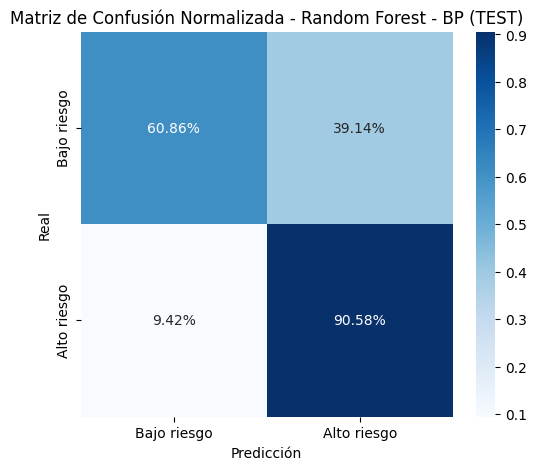

In [85]:
# Modelo Random Forest con class_weight='balanced'
modelo_rf_balanced_weight = RandomForestClassifier(
    max_depth=5,
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

modelo_rf_balanced_weight.fit(X_train_etapa_1, y_train)

rf_balanced_weight_metrics = evaluar_overfitting(
    modelo_rf_balanced_weight,
    X_train_etapa_1, y_train,
    X_test_etapa_1, y_test,
    threshold=0.4,
    nombre="Random Forest - BP"
)

results.append({"Modelo": "Random Forest BP", **rf_balanced_weight_metrics})

### **xgboost**


===== XGBoost - BP ====
---- TRAIN ----
AUC: 0.8723
Recall: 0.9150
Precision: 0.2642
F1: 0.4100

---- TEST ----
AUC: 0.8449
Recall: 0.8913
Precision: 0.2623
F1: 0.4053

---- GAP (Train-Test) ----
AUC gap: 0.0275
Recall gap: 0.0237


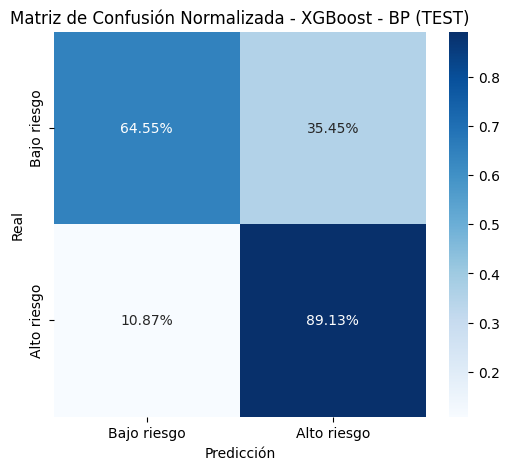

In [86]:
from xgboost import XGBClassifier

# ratio clases para penalización
ratio = (y_train == 0).sum() / (y_train == 1).sum() #9.55

modelo_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.6,
    colsample_bytree=0.8,
    min_child_weight=2,
    scale_pos_weight=ratio,
    eval_metric="aucpr",
    random_state=42
)

modelo_xgb.fit(X_train_etapa_1, y_train)

xgb_metrics = evaluar_overfitting(
    modelo_xgb,
    X_train_etapa_1, y_train,
    X_test_etapa_1, y_test,
    threshold=0.4,
    nombre="XGBoost - BP"
)

results.append({"Modelo": "XGBoost - BP", **xgb_metrics})

### **ramdom forrest con undersampling**

In [87]:
from imblearn.under_sampling import RandomUnderSampler

undersampler = RandomUnderSampler(
    sampling_strategy=0.8,
    random_state=42
)

X_train_under, y_train_under = undersampler.fit_resample(X_train_etapa_1, y_train)

print("Antes Undersampling:")
print(y_train.value_counts())

print("\nDespués Undersampling:")
print(y_train_under.value_counts())

Antes Undersampling:
alto_riesgo
0    3901
1     553
Name: count, dtype: int64

Después Undersampling:
alto_riesgo
0    691
1    553
Name: count, dtype: int64



===== Random Forest (Undersampling) ====
---- TRAIN ----
AUC: 0.9007
Recall: 0.9259
Precision: 0.6910
F1: 0.7913

---- TEST ----
AUC: 0.8420
Recall: 0.8768
Precision: 0.2602
F1: 0.4013

---- GAP (Train-Test) ----
AUC gap: 0.0588
Recall gap: 0.0490


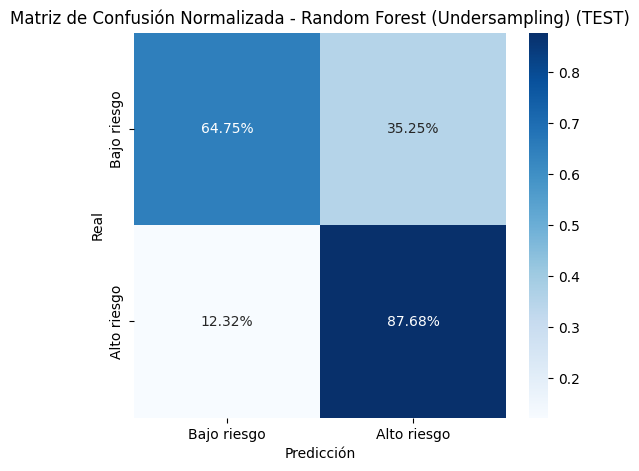

In [88]:
from sklearn.ensemble import RandomForestClassifier

# Modelo Random Forest con Undersampling
modelo_rf_under = RandomForestClassifier(
    max_depth=5,
    n_estimators=100,
    random_state=42
)

modelo_rf_under.fit(X_train_under, y_train_under)

rf_under_metrics = evaluar_overfitting(
    modelo_rf_under,
    X_train_under, y_train_under,
    X_test_etapa_1, y_test,
    threshold=0.4,
    nombre="Random Forest (Undersampling)"
)

results.append({"Modelo": "Random Forest (Undersampling)", **rf_under_metrics})

In [89]:
import pandas as pd

df_results = pd.DataFrame(results)

print("pruebas con balanceo:")
df_results

pruebas con balanceo:


,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.883229,0.945750,0.254377,0.400920,0.843008,0.905797,0.246548,0.387597,0.040221,0.039953
1,XGBoost - BP,0.872328,0.915009,0.264230,0.410049,0.844871,0.891304,0.262260,0.405272,0.027457,0.023705
2,Random Forest (Undersampling),0.900736,0.925859,0.690958,0.791345,0.841953,0.876812,0.260215,0.401327,0.058783,0.049047


### Búsqueda de hiperparámetros con Optuna

In [90]:
pip install optuna

In [91]:
# # Inicializamos la lista para almacenar los resultados de los modelos
# results = []

# # Creamos un DataFrame vacío para los resultados iniciales
# df_results = pd.DataFrame(results)

### Búsqueda de hiperparámetros con Optuna para Random Forest - BP

In [92]:
import optuna

def objective_rf_balanced_weight(trial):
    # Hiperparámetros a optimizar
    max_depth = trial.suggest_int('max_depth', 3, 10)
    n_estimators = trial.suggest_int('n_estimators', 50, 300, step=50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

    model = RandomForestClassifier(
        max_depth=max_depth,
        n_estimators=n_estimators,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        class_weight='balanced'
    )

    # Entrenar el modelo
    model.fit(X_train_etapa_1, y_train)

    # Realizar predicciones en el conjunto de prueba
    prob_test = model.predict_proba(X_test_etapa_1)[:, 1]
    pred_test = (prob_test >= 0.4).astype(int) # Usamos el mismo threshold que en evaluar_overfitting

    recall = recall_score(y_test, pred_test)

    return recall

# Crear un estudio de Optuna y ejecutar la optimización
study_rf_balanced_weight = optuna.create_study(direction='maximize') # Queremos maximizar el recall
study_rf_balanced_weight.optimize(objective_rf_balanced_weight, n_trials=50)

print(f"Mejores parámetros con Optuna para RF (Class Weight Balanced): {study_rf_balanced_weight.best_params}")
print(f"Mejor recall con Optuna para RF (Class Weight Balanced) en validación: {study_rf_balanced_weight.best_value:.4f}")

[I 2026-03-22 03:53:03,764] A new study created in memory with name: no-name-0145e8c9-a826-48aa-9adb-af19ce2008ba
[I 2026-03-22 03:53:04,778] Trial 0 finished with value: 0.8623188405797102 and parameters: {'max_depth': 8, 'n_estimators': 150, 'min_samples_split': 9, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.8623188405797102.
[I 2026-03-22 03:53:05,276] Trial 1 finished with value: 0.9202898550724637 and parameters: {'max_depth': 4, 'n_estimators': 150, 'min_samples_split': 6, 'min_samples_leaf': 6}. Best is trial 1 with value: 0.9202898550724637.
[I 2026-03-22 03:53:06,158] Trial 2 finished with value: 0.9202898550724637 and parameters: {'max_depth': 4, 'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.9202898550724637.
[I 2026-03-22 03:53:08,482] Trial 3 finished with value: 0.8188405797101449 and parameters: {'max_depth': 10, 'n_estimators': 250, 'min_samples_split': 7, 'min_samples_leaf': 8}. Best is trial 1 with value:

Mejores parámetros con Optuna para RF (Class Weight Balanced): {'max_depth': 3, 'n_estimators': 250, 'min_samples_split': 14, 'min_samples_leaf': 6}
Mejor recall con Optuna para RF (Class Weight Balanced) en validación: 0.9493


### Evaluación del mejor modelo Random Forest - BP encontrado por Optuna


===== Random Forest - BP Optuna ====
---- TRAIN ----
AUC: 0.8553
Recall: 0.9512
Precision: 0.2234
F1: 0.3618

---- TEST ----
AUC: 0.8421
Recall: 0.9493
Precision: 0.2255
F1: 0.3644

---- GAP (Train-Test) ----
AUC gap: 0.0132
Recall gap: 0.0019


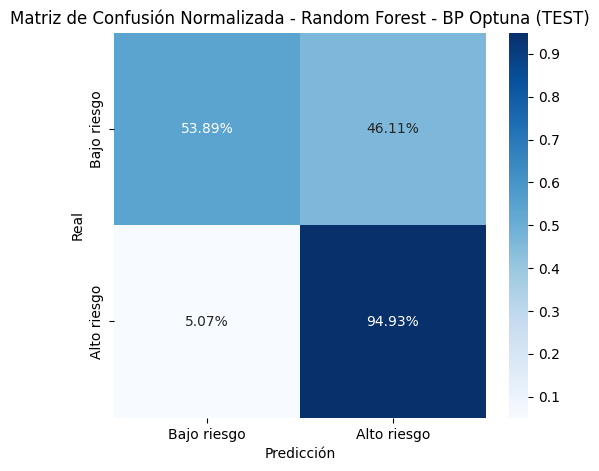

,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.883229,0.945750,0.254377,0.400920,0.843008,0.905797,0.246548,0.387597,0.040221,0.039953
1,XGBoost - BP,0.872328,0.915009,0.264230,0.410049,0.844871,0.891304,0.262260,0.405272,0.027457,0.023705
2,Random Forest (Undersampling),0.900736,0.925859,0.690958,0.791345,0.841953,0.876812,0.260215,0.401327,0.058783,0.049047
3,Random Forest - BP Optuna,0.855332,0.951175,0.223355,0.361761,0.842146,0.949275,0.225473,0.364395,0.013186,0.001900


In [93]:
# Obtener el mejor modelo de Optuna
best_rf_balanced_weight_optuna_model = RandomForestClassifier(
    **study_rf_balanced_weight.best_params,
    random_state=42,
    class_weight='balanced'
)
best_rf_balanced_weight_optuna_model.fit(X_train_etapa_1, y_train)

# Evaluar el mejor modelo en los conjuntos de entrenamiento y prueba
best_rf_balanced_weight_optuna_metrics = evaluar_overfitting(
    best_rf_balanced_weight_optuna_model,
    X_train_etapa_1, y_train,
    X_test_etapa_1, y_test,
    threshold=0.4,
    nombre="Random Forest - BP Optuna"
)

results.append({"Modelo": "Random Forest - BP Optuna", **best_rf_balanced_weight_optuna_metrics})

# Mostrar los resultados actualizados
df_results = pd.DataFrame(results)
display(df_results)

### Búsqueda de hiperparámetros con Optuna para XGBoost

In [94]:
import optuna
from xgboost import XGBClassifier

def objective_xgb(trial):
    # Hiperparámetros a optimizar
    n_estimators = trial.suggest_int('n_estimators', 100, 500, step=100)
    max_depth = trial.suggest_int('max_depth', 2, 8)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.1, log=True)
    subsample = trial.suggest_float('subsample', 0.5, 0.9)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 0.9)
    min_child_weight = trial.suggest_int('min_child_weight', 1, 10)

    # Inicializar el modelo XGBoost con scale_pos_weight
    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        min_child_weight=min_child_weight,
        scale_pos_weight=ratio, # ratio calculado previamente
        eval_metric='aucpr',
        random_state=42,
        use_label_encoder=False # Suprime la advertencia de desuso
    )

    # Entrenar el modelo
    model.fit(X_train_etapa_1, y_train)

    # Realizar predicciones en el conjunto de prueba
    prob_test = model.predict_proba(X_test_etapa_1)[:, 1]
    pred_test = (prob_test >= 0.4).astype(int) # mismo threshold que en evaluar_overfitting

    recall = recall_score(y_test, pred_test)

    return recall

study_xgb = optuna.create_study(direction='maximize') # maximizar el recall
study_xgb.optimize(objective_xgb, n_trials=50)

print(f"Mejores parámetros con Optuna para XGBoost: {study_xgb.best_params}")
print(f"Mejor recall con Optuna para XGBoost en validación: {study_xgb.best_value:.4f}")

[I 2026-03-22 03:54:04,380] A new study created in memory with name: no-name-f5130f93-8c82-4f0a-8a54-061bea187aec
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:54:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2026-03-22 03:54:05,449] Trial 0 finished with value: 0.6521739130434783 and parameters: {'n_estimators': 400, 'max_depth': 7, 'learning_rate': 0.02581769191772548, 'subsample': 0.8340556746758865, 'colsample_bytree': 0.8766155883976574, 'min_child_weight': 5}. Best is trial 0 with value: 0.6521739130434783.
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:54:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2026-03-22 03:54:08,071] Trial 1 finished with value: 0.5362318840579711 and parameters: {'n_estimat

Mejores parámetros con Optuna para XGBoost: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.010106372516351216, 'subsample': 0.8190154661332406, 'colsample_bytree': 0.7156926014224468, 'min_child_weight': 10}
Mejor recall con Optuna para XGBoost en validación: 0.9203


### Evaluación del mejor modelo XGBoost encontrado por Optuna

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:54:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



===== XGBoost (Optuna) ====
---- TRAIN ----
AUC: 0.8617
Recall: 0.9584
Precision: 0.2285
F1: 0.3691

---- TEST ----
AUC: 0.8351
Recall: 0.9203
Precision: 0.2216
F1: 0.3572

---- GAP (Train-Test) ----
AUC gap: 0.0267
Recall gap: 0.0381


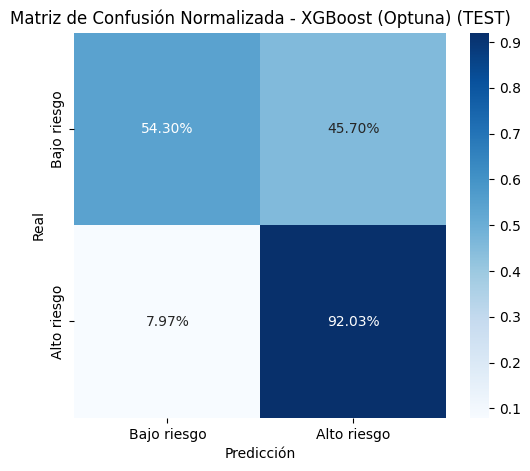

,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.883229,0.945750,0.254377,0.400920,0.843008,0.905797,0.246548,0.387597,0.040221,0.039953
1,XGBoost - BP,0.872328,0.915009,0.264230,0.410049,0.844871,0.891304,0.262260,0.405272,0.027457,0.023705
2,Random Forest (Undersampling),0.900736,0.925859,0.690958,0.791345,0.841953,0.876812,0.260215,0.401327,0.058783,0.049047
3,Random Forest - BP Optuna,0.855332,0.951175,0.223355,0.361761,0.842146,0.949275,0.225473,0.364395,0.013186,0.001900
4,XGBoost (Optuna),0.861738,0.958409,0.228547,0.369081,0.835052,0.920290,0.221640,0.357243,0.026685,0.038119


In [95]:
# Obtener el mejor modelo XGBoost de Optuna
best_xgb_optuna_model = XGBClassifier(
    **study_xgb.best_params,
    scale_pos_weight=ratio, # ratio calculado previamente
    eval_metric='aucpr',
    random_state=42,
    use_label_encoder=False # Suprime la advertencia de desuso
)
best_xgb_optuna_model.fit(X_train_etapa_1, y_train)

# Evaluar el mejor modelo en los conjuntos de entrenamiento y prueba
best_xgb_optuna_metrics = evaluar_overfitting(
    best_xgb_optuna_model,
    X_train_etapa_1, y_train,
    X_test_etapa_1, y_test,
    threshold=0.4,
    nombre="XGBoost (Optuna)"
)

results.append({"Modelo": "XGBoost (Optuna)", **best_xgb_optuna_metrics})

# Mostrar los resultados actualizados
df_results = pd.DataFrame(results)
display(df_results)

### Búsqueda de hiperparámetros con Optuna para Random Forest (Undersampling)

In [96]:
import optuna
from imblearn.under_sampling import RandomUnderSampler

def objective_rf_undersampling(trial):
    # Hiperparámetros a optimizar
    max_depth = trial.suggest_int('max_depth', 3, 10)
    n_estimators = trial.suggest_int('n_estimators', 50, 300, step=50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

    # Inicializar el modelo Random Forest
    model = RandomForestClassifier(
        max_depth=max_depth,
        n_estimators=n_estimators,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )


    undersampler = RandomUnderSampler(
        sampling_strategy=0.8,
        random_state=42
    )
    X_train_under_trial, y_train_under_trial = undersampler.fit_resample(X_train_etapa_1, y_train)

    model.fit(X_train_under_trial, y_train_under_trial)

    prob_test = model.predict_proba(X_test_etapa_1)[:, 1]
    pred_test = (prob_test >= 0.4).astype(int)

    recall = recall_score(y_test, pred_test)

    return recall

# Crear un estudio de Optuna y ejecutar la optimización
study_rf_undersampling = optuna.create_study(direction='maximize')
study_rf_undersampling.optimize(objective_rf_undersampling, n_trials=50)

print(f"Mejores parámetros con Optuna para RF (Undersampling): {study_rf_undersampling.best_params}")
print(f"Mejor recall con Optuna para RF (Undersampling) en validación: {study_rf_undersampling.best_value:.4f}")

[I 2026-03-22 03:54:49,117] A new study created in memory with name: no-name-4a3ae12d-1288-4bd0-b18c-e58dee528051
[I 2026-03-22 03:54:49,659] Trial 0 finished with value: 0.855072463768116 and parameters: {'max_depth': 9, 'n_estimators': 200, 'min_samples_split': 13, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.855072463768116.
[I 2026-03-22 03:54:50,307] Trial 1 finished with value: 0.8478260869565217 and parameters: {'max_depth': 7, 'n_estimators': 250, 'min_samples_split': 5, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.855072463768116.
[I 2026-03-22 03:54:50,539] Trial 2 finished with value: 0.8985507246376812 and parameters: {'max_depth': 3, 'n_estimators': 100, 'min_samples_split': 3, 'min_samples_leaf': 5}. Best is trial 2 with value: 0.8985507246376812.
[I 2026-03-22 03:54:50,680] Trial 3 finished with value: 0.855072463768116 and parameters: {'max_depth': 7, 'n_estimators': 50, 'min_samples_split': 20, 'min_samples_leaf': 1}. Best is trial 2 with value: 0.898

Mejores parámetros con Optuna para RF (Undersampling): {'max_depth': 3, 'n_estimators': 150, 'min_samples_split': 11, 'min_samples_leaf': 3}
Mejor recall con Optuna para RF (Undersampling) en validación: 0.9058


### Evaluación del mejor modelo Random Forest (Undersampling) encontrado por Optuna


===== Random Forest (Optuna - Under) ====
---- TRAIN ----
AUC: 0.8633
Recall: 0.9186
Precision: 0.6538
F1: 0.7639

---- TEST ----
AUC: 0.8376
Recall: 0.9058
Precision: 0.2546
F1: 0.3975

---- GAP (Train-Test) ----
AUC gap: 0.0257
Recall gap: 0.0128


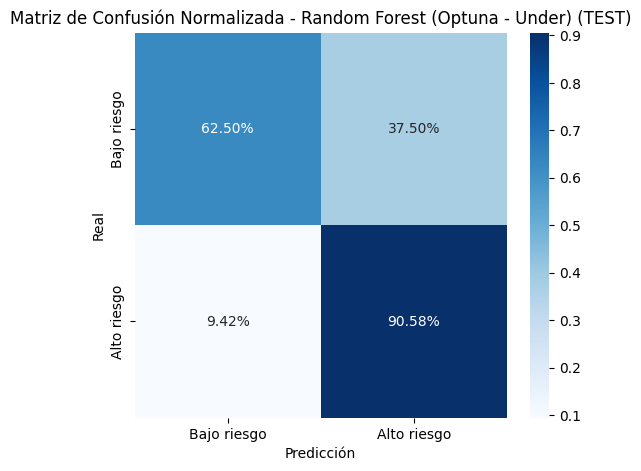


Resultados finales de todos los modelos optimizados con Optuna:


,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.883229,0.945750,0.254377,0.400920,0.843008,0.905797,0.246548,0.387597,0.040221,0.039953
1,XGBoost - BP,0.872328,0.915009,0.264230,0.410049,0.844871,0.891304,0.262260,0.405272,0.027457,0.023705
2,Random Forest (Undersampling),0.900736,0.925859,0.690958,0.791345,0.841953,0.876812,0.260215,0.401327,0.058783,0.049047
3,Random Forest - BP Optuna,0.855332,0.951175,0.223355,0.361761,0.842146,0.949275,0.225473,0.364395,0.013186,0.001900
4,XGBoost (Optuna),0.861738,0.958409,0.228547,0.369081,0.835052,0.920290,0.221640,0.357243,0.026685,0.038119
5,Random Forest (Optuna - Under),0.863267,0.918626,0.653797,0.763910,0.837595,0.905797,0.254582,0.397456,0.025672,0.012829


In [97]:
# Obtener el mejor modelo de Optuna
best_rf_undersampling_optuna_model = RandomForestClassifier(
    **study_rf_undersampling.best_params,
    random_state=42
)

# Aplicar undersampling una vez con los datos de entrenamiento para el modelo final
undersampler_final = RandomUnderSampler(
    sampling_strategy=0.8,
    random_state=42
)
X_train_under_final, y_train_under_final = undersampler_final.fit_resample(X_train_etapa_1, y_train)

best_rf_undersampling_optuna_model.fit(X_train_under_final, y_train_under_final)

# Evaluar el mejor modelo en los conjuntos de entrenamiento y prueba (no undersampled)
best_rf_undersampling_optuna_metrics = evaluar_overfitting(
    best_rf_undersampling_optuna_model,
    X_train_under_final, y_train_under_final, # Usar los datos undersampled para train metrics
    X_test_etapa_1, y_test,
    threshold=0.4,
    nombre="Random Forest (Optuna - Under)"
)

results.append({"Modelo": "Random Forest (Optuna - Under)", **best_rf_undersampling_optuna_metrics})

# Mostrar los resultados finales actualizados
df_results = pd.DataFrame(results)
print("\nResultados finales de todos los modelos optimizados con Optuna:")
display(df_results)

In [98]:
display(df_results)

,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.883229,0.945750,0.254377,0.400920,0.843008,0.905797,0.246548,0.387597,0.040221,0.039953
1,XGBoost - BP,0.872328,0.915009,0.264230,0.410049,0.844871,0.891304,0.262260,0.405272,0.027457,0.023705
2,Random Forest (Undersampling),0.900736,0.925859,0.690958,0.791345,0.841953,0.876812,0.260215,0.401327,0.058783,0.049047
3,Random Forest - BP Optuna,0.855332,0.951175,0.223355,0.361761,0.842146,0.949275,0.225473,0.364395,0.013186,0.001900
4,XGBoost (Optuna),0.861738,0.958409,0.228547,0.369081,0.835052,0.920290,0.221640,0.357243,0.026685,0.038119
5,Random Forest (Optuna - Under),0.863267,0.918626,0.653797,0.763910,0.837595,0.905797,0.254582,0.397456,0.025672,0.012829


### Preparación de datos para la Etapa 2 (Básicas + Antecedentes + Laboratorio)

In [99]:
# Definición de las columnas para la Etapa 2
nivel_3_cols = nivel_2_cols + [c for c in nivel_3_laboratorio if c in X_train.columns]

# Actualizar la lista de etapas y nombres de etapas para incluir la Etapa 2
etapas = [nivel_3_cols]
nombres_etapas = ["Etapa 2: Básica + Antecedentes + Laboratorio"]

# Preparar los conjuntos de datos para la Etapa 3
X_train_etapa_3 = X_train[etapas[0]]
X_test_etapa_3 = X_test[etapas[0]]

print(f"Columnas seleccionadas para la Etapa 3: {len(X_train_etapa_3.columns)}")
X_train_etapa_3.info()

Columnas seleccionadas para la Etapa 3: 44
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4454 entries, 0 to 4453
Data columns (total 44 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   edad                                   4454 non-null   float64
 1   genero                                 4454 non-null   int64  
 2   fumo_100_cigarrillos                   4454 non-null   int64  
 3   actividad_deportiva_moderada_x_semana  4454 non-null   float64
 4   anhedonia_1.0                          4454 non-null   float64
 5   anhedonia_2.0                          4454 non-null   float64
 6   anhedonia_9.0                          4454 non-null   float64
 7   anhedonia_3.0                          4454 non-null   float64
 8   consumo_alcohol_ultimo_año_1.0         4454 non-null   float64
 9   consumo_alcohol_ultimo_año_2.0         4454 non-null   float64
 10  consumo_alcohol_ultimo_año_3.

### Evaluación de modelos optimizados con datos de la Etapa 2

#### Re-evaluación: Random Forest - BP Optuna con etapa 2


===== Random Forest - BP Optuna Etapa 2 ====
---- TRAIN ----
AUC: 0.8632
Recall: 0.9566
Precision: 0.2287
F1: 0.3692

---- TEST ----
AUC: 0.8455
Recall: 0.9130
Precision: 0.2222
F1: 0.3574

---- GAP (Train-Test) ----
AUC gap: 0.0177
Recall gap: 0.0436


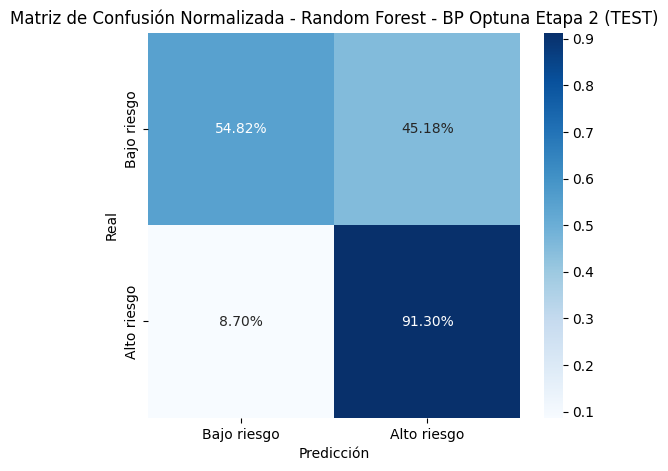

,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.883229,0.945750,0.254377,0.400920,0.843008,0.905797,0.246548,0.387597,0.040221,0.039953
1,XGBoost - BP,0.872328,0.915009,0.264230,0.410049,0.844871,0.891304,0.262260,0.405272,0.027457,0.023705
2,Random Forest (Undersampling),0.900736,0.925859,0.690958,0.791345,0.841953,0.876812,0.260215,0.401327,0.058783,0.049047
3,Random Forest - BP Optuna,0.855332,0.951175,0.223355,0.361761,0.842146,0.949275,0.225473,0.364395,0.013186,0.001900
4,XGBoost (Optuna),0.861738,0.958409,0.228547,0.369081,0.835052,0.920290,0.221640,0.357243,0.026685,0.038119
5,Random Forest (Optuna - Under),0.863267,0.918626,0.653797,0.763910,0.837595,0.905797,0.254582,0.397456,0.025672,0.012829
6,Random Forest - BP Optuna Etapa 2,0.863169,0.956600,0.228707,0.369156,0.845450,0.913043,0.222222,0.357447,0.017718,0.043557


In [100]:
# Obtener el mejor modelo de Optuna (hiperparámetros ya encontrados)
best_rf_balanced_weight_optuna_model_etapa3 = RandomForestClassifier(
    **study_rf_balanced_weight.best_params,
    random_state=42,
    class_weight='balanced'
)
best_rf_balanced_weight_optuna_model_etapa3.fit(X_train_etapa_3, y_train)

# Evaluar el mejor modelo en los conjuntos de entrenamiento y prueba de la Etapa 3
best_rf_balanced_weight_optuna_metrics_etapa3 = evaluar_overfitting(
    best_rf_balanced_weight_optuna_model_etapa3,
    X_train_etapa_3, y_train,
    X_test_etapa_3, y_test,
    threshold=0.4,
    nombre="Random Forest - BP Optuna Etapa 2"
)

results.append({"Modelo": "Random Forest - BP Optuna Etapa 2", **best_rf_balanced_weight_optuna_metrics_etapa3})

# Mostrar los resultados actualizados
df_results = pd.DataFrame(results)
display(df_results)

#### Re-evaluación: XGBoost (Optuna) con etapa 2

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:56:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



===== XGBoost (Optuna) Etapa 2 ====
---- TRAIN ----
AUC: 0.8728
Recall: 0.9620
Precision: 0.2309
F1: 0.3724

---- TEST ----
AUC: 0.8398
Recall: 0.9275
Precision: 0.2242
F1: 0.3611

---- GAP (Train-Test) ----
AUC gap: 0.0329
Recall gap: 0.0345


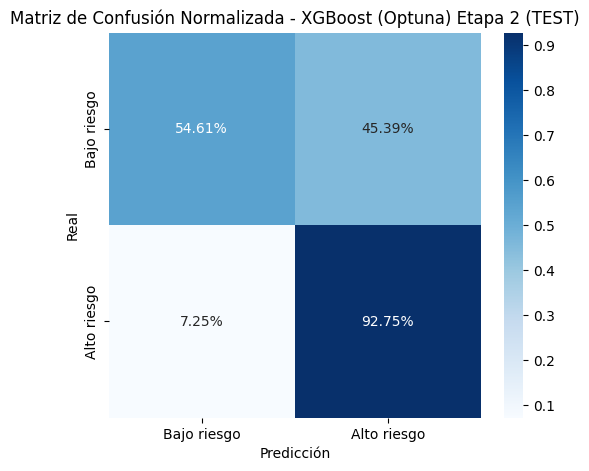

,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.883229,0.945750,0.254377,0.400920,0.843008,0.905797,0.246548,0.387597,0.040221,0.039953
1,XGBoost - BP,0.872328,0.915009,0.264230,0.410049,0.844871,0.891304,0.262260,0.405272,0.027457,0.023705
2,Random Forest (Undersampling),0.900736,0.925859,0.690958,0.791345,0.841953,0.876812,0.260215,0.401327,0.058783,0.049047
3,Random Forest - BP Optuna,0.855332,0.951175,0.223355,0.361761,0.842146,0.949275,0.225473,0.364395,0.013186,0.001900
4,XGBoost (Optuna),0.861738,0.958409,0.228547,0.369081,0.835052,0.920290,0.221640,0.357243,0.026685,0.038119
5,Random Forest (Optuna - Under),0.863267,0.918626,0.653797,0.763910,0.837595,0.905797,0.254582,0.397456,0.025672,0.012829
6,Random Forest - BP Optuna Etapa 2,0.863169,0.956600,0.228707,0.369156,0.845450,0.913043,0.222222,0.357447,0.017718,0.043557
7,XGBoost (Optuna) Etapa 2,0.872776,0.962025,0.230903,0.372419,0.839841,0.927536,0.224168,0.361072,0.032935,0.034489


In [101]:
# Obtener el mejor modelo XGBoost de Optuna (hiperparámetros ya encontrados)
best_xgb_optuna_model_etapa3 = XGBClassifier(
    **study_xgb.best_params,
    scale_pos_weight=ratio,
    eval_metric='aucpr',
    random_state=42,
    use_label_encoder=False
)
best_xgb_optuna_model_etapa3.fit(X_train_etapa_3, y_train)

# Evaluar el mejor modelo en los conjuntos de entrenamiento y prueba de la Etapa 2
best_xgb_optuna_metrics_etapa3 = evaluar_overfitting(
    best_xgb_optuna_model_etapa3,
    X_train_etapa_3, y_train,
    X_test_etapa_3, y_test,
    threshold=0.4,
    nombre="XGBoost (Optuna) Etapa 2"
)

results.append({"Modelo": "XGBoost (Optuna) Etapa 2", **best_xgb_optuna_metrics_etapa3})

# Mostrar los resultados actualizados
df_results = pd.DataFrame(results)
display(df_results)

#### Re-evaluación: Random Forest (Optuna - Undersampling) con Etapa 2


===== Random Forest Optuna - Under Etapa 2 ====
---- TRAIN ----
AUC: 0.8745
Recall: 0.8969
Precision: 0.6640
F1: 0.7631

---- TEST ----
AUC: 0.8451
Recall: 0.8841
Precision: 0.2521
F1: 0.3923

---- GAP (Train-Test) ----
AUC gap: 0.0294
Recall gap: 0.0129


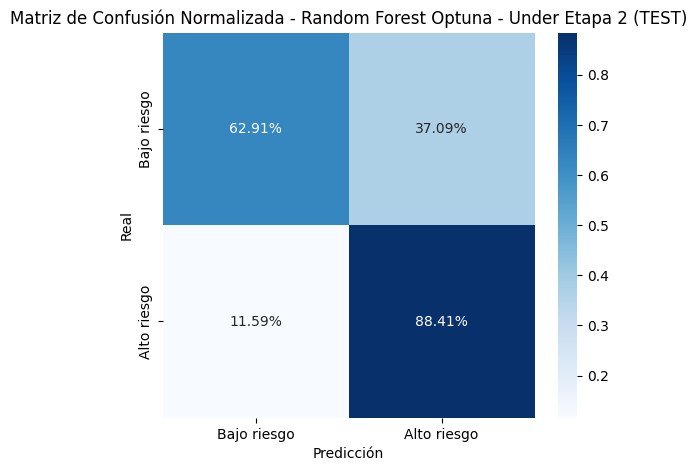

,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.883229,0.945750,0.254377,0.400920,0.843008,0.905797,0.246548,0.387597,0.040221,0.039953
1,XGBoost - BP,0.872328,0.915009,0.264230,0.410049,0.844871,0.891304,0.262260,0.405272,0.027457,0.023705
2,Random Forest (Undersampling),0.900736,0.925859,0.690958,0.791345,0.841953,0.876812,0.260215,0.401327,0.058783,0.049047
3,Random Forest - BP Optuna,0.855332,0.951175,0.223355,0.361761,0.842146,0.949275,0.225473,0.364395,0.013186,0.001900
4,XGBoost (Optuna),0.861738,0.958409,0.228547,0.369081,0.835052,0.920290,0.221640,0.357243,0.026685,0.038119
5,Random Forest (Optuna - Under),0.863267,0.918626,0.653797,0.763910,0.837595,0.905797,0.254582,0.397456,0.025672,0.012829
6,Random Forest - BP Optuna Etapa 2,0.863169,0.956600,0.228707,0.369156,0.845450,0.913043,0.222222,0.357447,0.017718,0.043557
7,XGBoost (Optuna) Etapa 2,0.872776,0.962025,0.230903,0.372419,0.839841,0.927536,0.224168,0.361072,0.032935,0.034489
8,Random Forest Optuna - Under Etapa 2,0.874544,0.896926,0.663989,0.763077,0.845138,0.884058,0.252066,0.392283,0.029406,0.012868


In [102]:
# Obtener el mejor modelo de Optuna (hiperparámetros ya encontrados)
best_rf_undersampling_optuna_model_etapa3 = RandomForestClassifier(
    **study_rf_undersampling.best_params,
    random_state=42
)

# Aplicar undersampling con los datos de entrenamiento de la Etapa 3 para el modelo final
undersampler_final_etapa3 = RandomUnderSampler(
    sampling_strategy=0.8,
    random_state=42
)
X_train_under_final_etapa3, y_train_under_final_etapa3 = undersampler_final_etapa3.fit_resample(X_train_etapa_3, y_train)

best_rf_undersampling_optuna_model_etapa3.fit(X_train_under_final_etapa3, y_train_under_final_etapa3)

# Evaluar el mejor modelo en los conjuntos de entrenamiento y prueba de la Etapa 3 (datos undersampled para train metrics)
best_rf_undersampling_optuna_metrics_etapa3 = evaluar_overfitting(
    best_rf_undersampling_optuna_model_etapa3,
    X_train_under_final_etapa3, y_train_under_final_etapa3,
    X_test_etapa_3, y_test,
    threshold=0.4,
    nombre="Random Forest Optuna - Under Etapa 2"
)

results.append({"Modelo": "Random Forest Optuna - Under Etapa 2", **best_rf_undersampling_optuna_metrics_etapa3})

# Mostrar los resultados finales actualizados
df_results = pd.DataFrame(results)
display(df_results)

In [104]:
display(df_results)

,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.883229,0.945750,0.254377,0.400920,0.843008,0.905797,0.246548,0.387597,0.040221,0.039953
1,XGBoost - BP,0.872328,0.915009,0.264230,0.410049,0.844871,0.891304,0.262260,0.405272,0.027457,0.023705
2,Random Forest (Undersampling),0.900736,0.925859,0.690958,0.791345,0.841953,0.876812,0.260215,0.401327,0.058783,0.049047
3,Random Forest - BP Optuna,0.855332,0.951175,0.223355,0.361761,0.842146,0.949275,0.225473,0.364395,0.013186,0.001900
4,XGBoost (Optuna),0.861738,0.958409,0.228547,0.369081,0.835052,0.920290,0.221640,0.357243,0.026685,0.038119
5,Random Forest (Optuna - Under),0.863267,0.918626,0.653797,0.763910,0.837595,0.905797,0.254582,0.397456,0.025672,0.012829
6,Random Forest - BP Optuna Etapa 2,0.863169,0.956600,0.228707,0.369156,0.845450,0.913043,0.222222,0.357447,0.017718,0.043557
7,XGBoost (Optuna) Etapa 2,0.872776,0.962025,0.230903,0.372419,0.839841,0.927536,0.224168,0.361072,0.032935,0.034489
8,Random Forest Optuna - Under Etapa 2,0.874544,0.896926,0.663989,0.763077,0.845138,0.884058,0.252066,0.392283,0.029406,0.012868


## Ahora se van a buscar hiperparámetros nuevos para los datos que incluyen la etapa 2

### Búsqueda de hiperparámetros con Optuna para Random Forest - BP - Etapa 2

In [105]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score

def objective_rf_balanced_weight_etapa3(trial):
    # Hiperparámetros a optimizar
    max_depth = trial.suggest_int('max_depth', 3, 10)
    n_estimators = trial.suggest_int('n_estimators', 50, 300, step=50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

    # Inicializar el modelo Random Forest con class_weight='balanced'
    model = RandomForestClassifier(
        max_depth=max_depth,
        n_estimators=n_estimators,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        class_weight='balanced'
    )

    model.fit(X_train_etapa_3, y_train)

    prob_test = model.predict_proba(X_test_etapa_3)[:, 1]
    pred_test = (prob_test >= 0.4).astype(int)

    recall = recall_score(y_test, pred_test)

    return recall

study_rf_balanced_weight_etapa3 = optuna.create_study(direction='maximize')
study_rf_balanced_weight_etapa3.optimize(objective_rf_balanced_weight_etapa3, n_trials=50)

print(f"Mejores parámetros con Optuna para RF (Class Weight Balanced) Etapa 3: {study_rf_balanced_weight_etapa3.best_params}")
print(f"Mejor recall con Optuna para RF (Class Weight Balanced) Etapa 3 en validación: {study_rf_balanced_weight_etapa3.best_value:.4f}")

[I 2026-03-22 04:06:48,223] A new study created in memory with name: no-name-ad5a4fdc-dbab-4cc1-92f5-9336b126e6bd
[I 2026-03-22 04:06:48,594] Trial 0 finished with value: 0.7971014492753623 and parameters: {'max_depth': 10, 'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.7971014492753623.
[I 2026-03-22 04:06:50,018] Trial 1 finished with value: 0.9057971014492754 and parameters: {'max_depth': 5, 'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 10}. Best is trial 1 with value: 0.9057971014492754.
[I 2026-03-22 04:06:51,740] Trial 2 finished with value: 0.8840579710144928 and parameters: {'max_depth': 7, 'n_estimators': 300, 'min_samples_split': 17, 'min_samples_leaf': 10}. Best is trial 1 with value: 0.9057971014492754.
[I 2026-03-22 04:06:52,654] Trial 3 finished with value: 0.8405797101449275 and parameters: {'max_depth': 7, 'n_estimators': 150, 'min_samples_split': 4, 'min_samples_leaf': 4}. Best is trial 1 with val

Mejores parámetros con Optuna para RF (Class Weight Balanced) Etapa 3: {'max_depth': 3, 'n_estimators': 150, 'min_samples_split': 12, 'min_samples_leaf': 5}
Mejor recall con Optuna para RF (Class Weight Balanced) Etapa 3 en validación: 0.9348


### Evaluación del mejor modelo Random Forest -BP encontrado por Optuna - Etapa 2


===== Random Forest - BP Optuna Re-optimizado Etapa 2 ====
---- TRAIN ----
AUC: 0.8642
Recall: 0.9566
Precision: 0.2306
F1: 0.3716

---- TEST ----
AUC: 0.8482
Recall: 0.9348
Precision: 0.2251
F1: 0.3629

---- GAP (Train-Test) ----
AUC gap: 0.0160
Recall gap: 0.0218


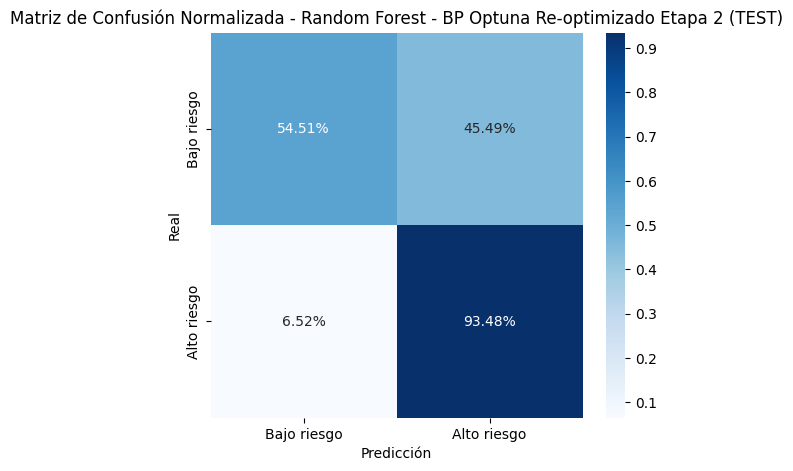

,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.883229,0.945750,0.254377,0.400920,0.843008,0.905797,0.246548,0.387597,0.040221,0.039953
1,XGBoost - BP,0.872328,0.915009,0.264230,0.410049,0.844871,0.891304,0.262260,0.405272,0.027457,0.023705
2,Random Forest (Undersampling),0.900736,0.925859,0.690958,0.791345,0.841953,0.876812,0.260215,0.401327,0.058783,0.049047
3,Random Forest - BP Optuna,0.855332,0.951175,0.223355,0.361761,0.842146,0.949275,0.225473,0.364395,0.013186,0.001900
4,XGBoost (Optuna),0.861738,0.958409,0.228547,0.369081,0.835052,0.920290,0.221640,0.357243,0.026685,0.038119
5,Random Forest (Optuna - Under),0.863267,0.918626,0.653797,0.763910,0.837595,0.905797,0.254582,0.397456,0.025672,0.012829
6,Random Forest - BP Optuna Etapa 2,0.863169,0.956600,0.228707,0.369156,0.845450,0.913043,0.222222,0.357447,0.017718,0.043557
7,XGBoost (Optuna) Etapa 2,0.872776,0.962025,0.230903,0.372419,0.839841,0.927536,0.224168,0.361072,0.032935,0.034489
8,Random Forest Optuna - Under Etapa 2,0.874544,0.896926,0.663989,0.763077,0.845138,0.884058,0.252066,0.392283,0.029406,0.012868
9,Random Forest - BP Optuna Re-optimizado Etapa 2,0.864249,0.956600,0.230602,0.371619,0.848242,0.934783,0.225131,0.362869,0.016007,0.021818


In [106]:
# Obtener el mejor modelo de Optuna para la Etapa 2
best_rf_balanced_weight_optuna_model_etapa3_reoptimized = RandomForestClassifier(
    **study_rf_balanced_weight_etapa3.best_params,
    random_state=42,
    class_weight='balanced'
)
best_rf_balanced_weight_optuna_model_etapa3_reoptimized.fit(X_train_etapa_3, y_train)

# Evaluar el mejor modelo en los conjuntos de entrenamiento y prueba de la Etapa 3
best_rf_balanced_weight_optuna_metrics_etapa3_reoptimized = evaluar_overfitting(
    best_rf_balanced_weight_optuna_model_etapa3_reoptimized,
    X_train_etapa_3, y_train,
    X_test_etapa_3, y_test,
    threshold=0.4,
    nombre="Random Forest - BP Optuna Re-optimizado Etapa 2"
)

results.append({"Modelo": "Random Forest - BP Optuna Re-optimizado Etapa 2", **best_rf_balanced_weight_optuna_metrics_etapa3_reoptimized})

# Mostrar los resultados actualizados
df_results = pd.DataFrame(results)
display(df_results)

### Búsqueda de hiperparámetros con Optuna para XGBoost - Etapa 2

In [107]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import recall_score

def objective_xgb_etapa3(trial):
    # Hiperparámetros a optimizar
    n_estimators = trial.suggest_int('n_estimators', 100, 500, step=100)
    max_depth = trial.suggest_int('max_depth', 2, 8)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.1, log=True)
    subsample = trial.suggest_float('subsample', 0.5, 0.9)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 0.9)
    min_child_weight = trial.suggest_int('min_child_weight', 1, 10)

    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        min_child_weight=min_child_weight,
        scale_pos_weight=ratio,
        eval_metric='aucpr',
        random_state=42,
        use_label_encoder=False
    )

    model.fit(X_train_etapa_3, y_train)

    prob_test = model.predict_proba(X_test_etapa_3)[:, 1]
    pred_test = (prob_test >= 0.4).astype(int)

    recall = recall_score(y_test, pred_test)

    return recall

study_xgb_etapa3 = optuna.create_study(direction='maximize')
study_xgb_etapa3.optimize(objective_xgb_etapa3, n_trials=50)

print(f"Mejores parámetros con Optuna para XGBoost Etapa 3: {study_xgb_etapa3.best_params}")
print(f"Mejor recall con Optuna para XGBoost Etapa 3 en validación: {study_xgb_etapa3.best_value:.4f}")

[I 2026-03-22 04:07:27,668] A new study created in memory with name: no-name-d1e3a7cf-b0d7-4dcf-8d30-f9a3180c2c4c
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:07:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2026-03-22 04:07:28,134] Trial 0 finished with value: 0.9202898550724637 and parameters: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.019529419420894457, 'subsample': 0.6069069984747564, 'colsample_bytree': 0.5786179862684454, 'min_child_weight': 2}. Best is trial 0 with value: 0.9202898550724637.
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:07:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2026-03-22 04:07:32,518] Trial 1 finished with value: 0.6376811594202898 and parameters: {'n_estima

Mejores parámetros con Optuna para XGBoost Etapa 3: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.010136915068390569, 'subsample': 0.5468143845223271, 'colsample_bytree': 0.773721218609404, 'min_child_weight': 2}
Mejor recall con Optuna para XGBoost Etapa 3 en validación: 0.9275


### Evaluación del mejor modelo XGBoost encontrado por Optuna - Etapa 2

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:07:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



===== XGBoost (Optuna) Re-optimizado Etapa 2 ====
---- TRAIN ----
AUC: 0.8737
Recall: 0.9620
Precision: 0.2351
F1: 0.3778

---- TEST ----
AUC: 0.8399
Recall: 0.9275
Precision: 0.2278
F1: 0.3657

---- GAP (Train-Test) ----
AUC gap: 0.0338
Recall gap: 0.0345


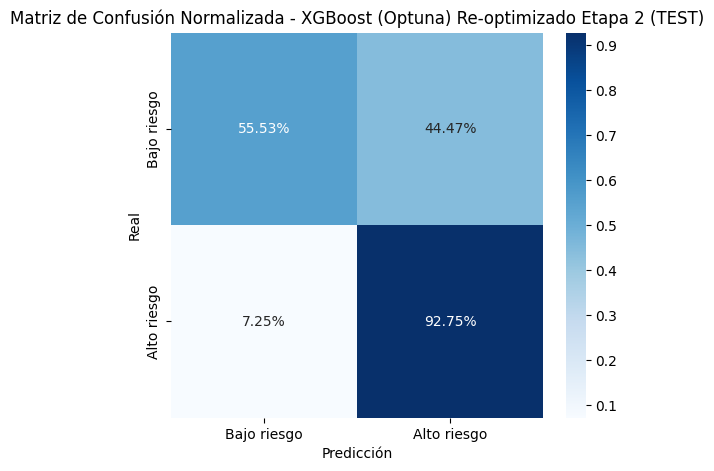

,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.883229,0.945750,0.254377,0.400920,0.843008,0.905797,0.246548,0.387597,0.040221,0.039953
1,XGBoost - BP,0.872328,0.915009,0.264230,0.410049,0.844871,0.891304,0.262260,0.405272,0.027457,0.023705
2,Random Forest (Undersampling),0.900736,0.925859,0.690958,0.791345,0.841953,0.876812,0.260215,0.401327,0.058783,0.049047
3,Random Forest - BP Optuna,0.855332,0.951175,0.223355,0.361761,0.842146,0.949275,0.225473,0.364395,0.013186,0.001900
4,XGBoost (Optuna),0.861738,0.958409,0.228547,0.369081,0.835052,0.920290,0.221640,0.357243,0.026685,0.038119
5,Random Forest (Optuna - Under),0.863267,0.918626,0.653797,0.763910,0.837595,0.905797,0.254582,0.397456,0.025672,0.012829
6,Random Forest - BP Optuna Etapa 2,0.863169,0.956600,0.228707,0.369156,0.845450,0.913043,0.222222,0.357447,0.017718,0.043557
7,XGBoost (Optuna) Etapa 2,0.872776,0.962025,0.230903,0.372419,0.839841,0.927536,0.224168,0.361072,0.032935,0.034489
8,Random Forest Optuna - Under Etapa 2,0.874544,0.896926,0.663989,0.763077,0.845138,0.884058,0.252066,0.392283,0.029406,0.012868
9,Random Forest - BP Optuna Re-optimizado Etapa 2,0.864249,0.956600,0.230602,0.371619,0.848242,0.934783,0.225131,0.362869,0.016007,0.021818


In [108]:
best_xgb_optuna_model_etapa3_reoptimized = XGBClassifier(
    **study_xgb_etapa3.best_params,
    scale_pos_weight=ratio,
    eval_metric='aucpr',
    random_state=42,
    use_label_encoder=False
)
best_xgb_optuna_model_etapa3_reoptimized.fit(X_train_etapa_3, y_train)

best_xgb_optuna_metrics_etapa3_reoptimized = evaluar_overfitting(
    best_xgb_optuna_model_etapa3_reoptimized,
    X_train_etapa_3, y_train,
    X_test_etapa_3, y_test,
    threshold=0.4,
    nombre="XGBoost (Optuna) Re-optimizado Etapa 2"
)

results.append({"Modelo": "XGBoost (Optuna) Re-optimizado Etapa 2", **best_xgb_optuna_metrics_etapa3_reoptimized})

# Mostrar los resultados actualizados
df_results = pd.DataFrame(results)
display(df_results)

### Búsqueda de hiperparámetros con Optuna para Random Forest (Undersampling) - Etapa 2

In [109]:
import optuna
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score

def objective_rf_undersampling_etapa3(trial):
    # Hiperparámetros a optimizar
    max_depth = trial.suggest_int('max_depth', 3, 10)
    n_estimators = trial.suggest_int('n_estimators', 50, 300, step=50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

    # Inicializar el modelo Random Forest
    model = RandomForestClassifier(
        max_depth=max_depth,
        n_estimators=n_estimators,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )

    undersampler = RandomUnderSampler(
        sampling_strategy=0.8,
        random_state=42
    )
    X_train_under_trial_etapa3, y_train_under_trial_etapa3 = undersampler.fit_resample(X_train_etapa_3, y_train)

    model.fit(X_train_under_trial_etapa3, y_train_under_trial_etapa3)

    prob_test = model.predict_proba(X_test_etapa_3)[:, 1]
    pred_test = (prob_test >= 0.4).astype(int)

    recall = recall_score(y_test, pred_test)

    return recall

study_rf_undersampling_etapa3 = optuna.create_study(direction='maximize')
study_rf_undersampling_etapa3.optimize(objective_rf_undersampling_etapa3, n_trials=50)

print(f"Mejores parámetros con Optuna para RF (Undersampling) Etapa 3: {study_rf_undersampling_etapa3.best_params}")
print(f"Mejor recall con Optuna para RF (Undersampling) Etapa 3 en validación: {study_rf_undersampling_etapa3.best_value:.4f}")

[I 2026-03-22 04:07:54,655] A new study created in memory with name: no-name-80213f48-cc62-4cca-b09c-8c24bee88d71
[I 2026-03-22 04:07:55,240] Trial 0 finished with value: 0.8913043478260869 and parameters: {'max_depth': 3, 'n_estimators': 250, 'min_samples_split': 17, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.8913043478260869.
[I 2026-03-22 04:07:55,613] Trial 1 finished with value: 0.8913043478260869 and parameters: {'max_depth': 4, 'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.8913043478260869.
[I 2026-03-22 04:07:55,787] Trial 2 finished with value: 0.8478260869565217 and parameters: {'max_depth': 10, 'n_estimators': 50, 'min_samples_split': 6, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.8913043478260869.
[I 2026-03-22 04:07:56,314] Trial 3 finished with value: 0.8840579710144928 and parameters: {'max_depth': 4, 'n_estimators': 200, 'min_samples_split': 12, 'min_samples_leaf': 4}. Best is trial 0 with value

Mejores parámetros con Optuna para RF (Undersampling) Etapa 3: {'max_depth': 4, 'n_estimators': 250, 'min_samples_split': 17, 'min_samples_leaf': 1}
Mejor recall con Optuna para RF (Undersampling) Etapa 3 en validación: 0.8986


### Evaluación del mejor modelo Random Forest (Undersampling) encontrado por Optuna - Etapa 2


===== Random Forest (Optuna - Under) Re-optimizado Etapa 2 ====
---- TRAIN ----
AUC: 0.8912
Recall: 0.9132
Precision: 0.6861
F1: 0.7836

---- TEST ----
AUC: 0.8455
Recall: 0.8986
Precision: 0.2725
F1: 0.4182

---- GAP (Train-Test) ----
AUC gap: 0.0457
Recall gap: 0.0146


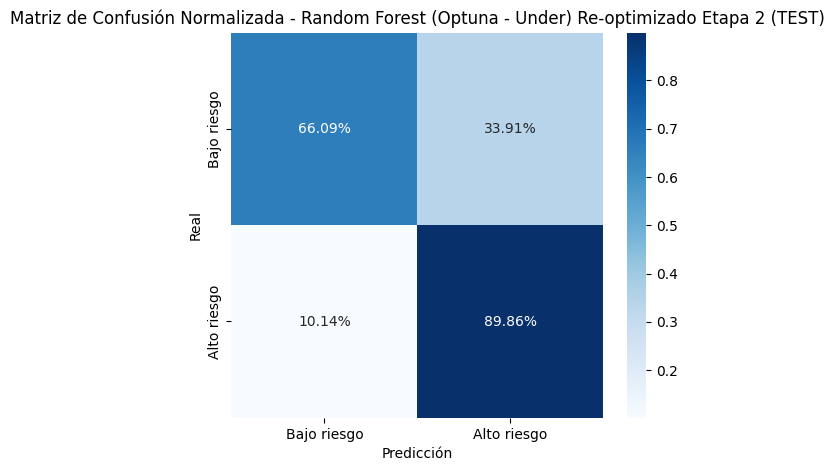

,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.883229,0.945750,0.254377,0.400920,0.843008,0.905797,0.246548,0.387597,0.040221,0.039953
1,XGBoost - BP,0.872328,0.915009,0.264230,0.410049,0.844871,0.891304,0.262260,0.405272,0.027457,0.023705
2,Random Forest (Undersampling),0.900736,0.925859,0.690958,0.791345,0.841953,0.876812,0.260215,0.401327,0.058783,0.049047
3,Random Forest - BP Optuna,0.855332,0.951175,0.223355,0.361761,0.842146,0.949275,0.225473,0.364395,0.013186,0.001900
4,XGBoost (Optuna),0.861738,0.958409,0.228547,0.369081,0.835052,0.920290,0.221640,0.357243,0.026685,0.038119
5,Random Forest (Optuna - Under),0.863267,0.918626,0.653797,0.763910,0.837595,0.905797,0.254582,0.397456,0.025672,0.012829
6,Random Forest - BP Optuna Etapa 2,0.863169,0.956600,0.228707,0.369156,0.845450,0.913043,0.222222,0.357447,0.017718,0.043557
7,XGBoost (Optuna) Etapa 2,0.872776,0.962025,0.230903,0.372419,0.839841,0.927536,0.224168,0.361072,0.032935,0.034489
8,Random Forest Optuna - Under Etapa 2,0.874544,0.896926,0.663989,0.763077,0.845138,0.884058,0.252066,0.392283,0.029406,0.012868
9,Random Forest - BP Optuna Re-optimizado Etapa 2,0.864249,0.956600,0.230602,0.371619,0.848242,0.934783,0.225131,0.362869,0.016007,0.021818


In [110]:
# Obtener el mejor modelo de Optuna para la Etapa 2
best_rf_undersampling_optuna_model_etapa3_reoptimized = RandomForestClassifier(
    **study_rf_undersampling_etapa3.best_params,
    random_state=42
)

undersampler_final_etapa3_reoptimized = RandomUnderSampler(
    sampling_strategy=0.8,
    random_state=42
)
X_train_under_final_etapa3_reoptimized, y_train_under_final_etapa3_reoptimized = undersampler_final_etapa3_reoptimized.fit_resample(X_train_etapa_3, y_train)

best_rf_undersampling_optuna_model_etapa3_reoptimized.fit(X_train_under_final_etapa3_reoptimized, y_train_under_final_etapa3_reoptimized)

best_rf_undersampling_optuna_metrics_etapa3_reoptimized = evaluar_overfitting(
    best_rf_undersampling_optuna_model_etapa3_reoptimized,
    X_train_under_final_etapa3_reoptimized, y_train_under_final_etapa3_reoptimized,
    X_test_etapa_3, y_test,
    threshold=0.4,
    nombre="Random Forest (Optuna - Under) Re-optimizado Etapa 2"
)

results.append({"Modelo": "Random Forest (Optuna - Under) Re-optimizado Etapa 2", **best_rf_undersampling_optuna_metrics_etapa3_reoptimized})

# Mostrar los resultados finales actualizados
df_results = pd.DataFrame(results)
display(df_results)

In [113]:
display(df_results)

,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.883229,0.945750,0.254377,0.400920,0.843008,0.905797,0.246548,0.387597,0.040221,0.039953
1,XGBoost - BP,0.872328,0.915009,0.264230,0.410049,0.844871,0.891304,0.262260,0.405272,0.027457,0.023705
2,Random Forest (Undersampling),0.900736,0.925859,0.690958,0.791345,0.841953,0.876812,0.260215,0.401327,0.058783,0.049047
3,Random Forest - BP Optuna,0.855332,0.951175,0.223355,0.361761,0.842146,0.949275,0.225473,0.364395,0.013186,0.001900
4,XGBoost (Optuna),0.861738,0.958409,0.228547,0.369081,0.835052,0.920290,0.221640,0.357243,0.026685,0.038119
5,Random Forest (Optuna - Under),0.863267,0.918626,0.653797,0.763910,0.837595,0.905797,0.254582,0.397456,0.025672,0.012829
6,Random Forest - BP Optuna Etapa 2,0.863169,0.956600,0.228707,0.369156,0.845450,0.913043,0.222222,0.357447,0.017718,0.043557
7,XGBoost (Optuna) Etapa 2,0.872776,0.962025,0.230903,0.372419,0.839841,0.927536,0.224168,0.361072,0.032935,0.034489
8,Random Forest Optuna - Under Etapa 2,0.874544,0.896926,0.663989,0.763077,0.845138,0.884058,0.252066,0.392283,0.029406,0.012868
9,Random Forest - BP Optuna Re-optimizado Etapa 2,0.864249,0.956600,0.230602,0.371619,0.848242,0.934783,0.225131,0.362869,0.016007,0.021818


### **RAMDOM FOREST BP**

In [112]:
display(df_results.iloc[[0, 3, 6, 9]])

Resultados para modelos iniciales y re-optimizados:


,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.883229,0.945750,0.254377,0.400920,0.843008,0.905797,0.246548,0.387597,0.040221,0.039953
3,Random Forest - BP Optuna,0.855332,0.951175,0.223355,0.361761,0.842146,0.949275,0.225473,0.364395,0.013186,0.001900
6,Random Forest - BP Optuna Etapa 2,0.863169,0.956600,0.228707,0.369156,0.845450,0.913043,0.222222,0.357447,0.017718,0.043557
9,Random Forest - BP Optuna Re-optimizado Etapa 2,0.864249,0.956600,0.230602,0.371619,0.848242,0.934783,0.225131,0.362869,0.016007,0.021818


### **XGBOOST**

In [116]:
display(df_results.iloc[[1, 4, 7, 10]])

,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
1,XGBoost - BP,0.872328,0.915009,0.264230,0.410049,0.844871,0.891304,0.262260,0.405272,0.027457,0.023705
4,XGBoost (Optuna),0.861738,0.958409,0.228547,0.369081,0.835052,0.920290,0.221640,0.357243,0.026685,0.038119
7,XGBoost (Optuna) Etapa 2,0.872776,0.962025,0.230903,0.372419,0.839841,0.927536,0.224168,0.361072,0.032935,0.034489
10,XGBoost (Optuna) Re-optimizado Etapa 2,0.873672,0.962025,0.235086,0.377841,0.839911,0.927536,0.227758,0.365714,0.033761,0.034489


### **RAMDOM FORREST UNDER**

In [115]:
display(df_results.iloc[[2, 5, 8, 11]])

,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
2,Random Forest (Undersampling),0.900736,0.925859,0.690958,0.791345,0.841953,0.876812,0.260215,0.401327,0.058783,0.049047
5,Random Forest (Optuna - Under),0.863267,0.918626,0.653797,0.763910,0.837595,0.905797,0.254582,0.397456,0.025672,0.012829
8,Random Forest Optuna - Under Etapa 2,0.874544,0.896926,0.663989,0.763077,0.845138,0.884058,0.252066,0.392283,0.029406,0.012868
11,Random Forest (Optuna - Under) Re-optimizado E...,0.891203,0.913201,0.686141,0.783553,0.845539,0.898551,0.272527,0.418212,0.045663,0.014650


### Optimización del umbral de clasificación para XGBoost (Optuna) Re-optimizado Etapa 2

Mejor umbral encontrado: 0.0100 (Recall: 1.0000)

===== XGBoost (Optuna) Re-optimizado Etapa 2 - Umbral Óptimo ====
---- TRAIN ----
AUC: 0.8737
Recall: 1.0000
Precision: 0.1242
F1: 0.2209

---- TEST ----
AUC: 0.8399
Recall: 1.0000
Precision: 0.1239
F1: 0.2204

---- GAP (Train-Test) ----
AUC gap: 0.0338
Recall gap: 0.0000


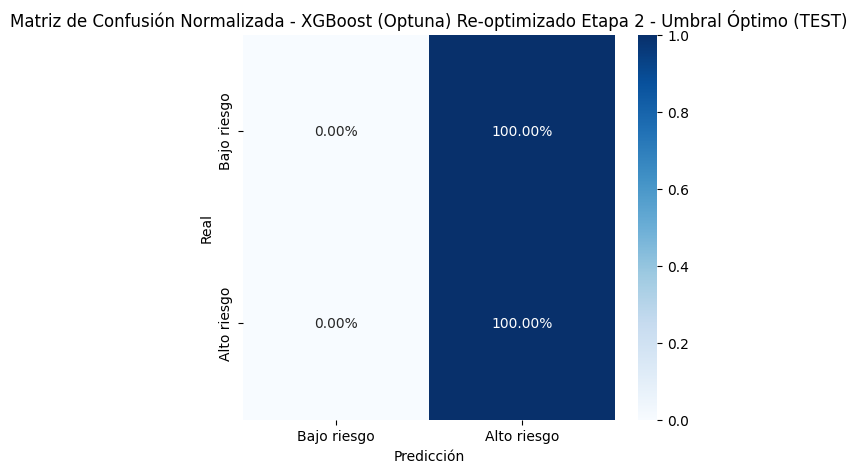

,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.883229,0.945750,0.254377,0.400920,0.843008,0.905797,0.246548,0.387597,0.040221,0.039953
1,XGBoost - BP,0.872328,0.915009,0.264230,0.410049,0.844871,0.891304,0.262260,0.405272,0.027457,0.023705
2,Random Forest (Undersampling),0.900736,0.925859,0.690958,0.791345,0.841953,0.876812,0.260215,0.401327,0.058783,0.049047
3,Random Forest - BP Optuna,0.855332,0.951175,0.223355,0.361761,0.842146,0.949275,0.225473,0.364395,0.013186,0.001900
4,XGBoost (Optuna),0.861738,0.958409,0.228547,0.369081,0.835052,0.920290,0.221640,0.357243,0.026685,0.038119
5,Random Forest (Optuna - Under),0.863267,0.918626,0.653797,0.763910,0.837595,0.905797,0.254582,0.397456,0.025672,0.012829
6,Random Forest - BP Optuna Etapa 2,0.863169,0.956600,0.228707,0.369156,0.845450,0.913043,0.222222,0.357447,0.017718,0.043557
7,XGBoost (Optuna) Etapa 2,0.872776,0.962025,0.230903,0.372419,0.839841,0.927536,0.224168,0.361072,0.032935,0.034489
8,Random Forest Optuna - Under Etapa 2,0.874544,0.896926,0.663989,0.763077,0.845138,0.884058,0.252066,0.392283,0.029406,0.012868
9,Random Forest - BP Optuna Re-optimizado Etapa 2,0.864249,0.956600,0.230602,0.371619,0.848242,0.934783,0.225131,0.362869,0.016007,0.021818


In [117]:
from sklearn.metrics import recall_score

def find_optimal_threshold(model, X_test, y_test):
    prob_test = model.predict_proba(X_test)[:, 1]
    thresholds = np.linspace(0.01, 0.99, 100)
    best_threshold = 0.4
    best_recall = 0

    for t in thresholds:
        pred_test = (prob_test >= t).astype(int)
        current_recall = recall_score(y_test, pred_test)
        if current_recall > best_recall:
            best_recall = current_recall
            best_threshold = t

    print(f"Mejor umbral encontrado: {best_threshold:.4f} (Recall: {best_recall:.4f})")
    return best_threshold

# Encontrar el umbral óptimo para el modelo XGBoost re-optimizado Etapa 2
optimal_threshold_xgb_etapa3 = find_optimal_threshold(
    best_xgb_optuna_model_etapa3_reoptimized,
    X_test_etapa_3, y_test
)

# Evaluar el modelo con el umbral óptimo
best_xgb_optuna_metrics_etapa3_optimal_threshold = evaluar_overfitting(
    best_xgb_optuna_model_etapa3_reoptimized,
    X_train_etapa_3, y_train,
    X_test_etapa_3, y_test,
    threshold=optimal_threshold_xgb_etapa3,
    nombre="XGBoost (Optuna) Re-optimizado Etapa 2 - Umbral Óptimo"
)

results.append({"Modelo": "XGBoost (Optuna) Re-optimizado Etapa 2 - Umbral Óptimo", **best_xgb_optuna_metrics_etapa3_optimal_threshold})

# Mostrar los resultados actualizados
df_results = pd.DataFrame(results)
display(df_results)